# Лабораторная работа №1 (продолжение)
# Анализ типов признаков, пропусков и статистик

Данный ноутбук является продолжением первичного исследования датасета blink.

Цель работы — углубленный анализ структуры данных, типов признаков,
природы пропусков, выбросов и статистических характеристик.

# Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('blink.csv')

# исправление структуры
df.columns = df.iloc[0]
df = df.drop(0).reset_index(drop=True)

# преобразование типов
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

df.head()

/tmp/ipykernel_249/3291610407.py:14: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


,id,anchorID,tagID,sequenceID,pan,processed_flag,timestampToA,Timestamp ToA
0,1,ANCH0001,TAG00001,0,0,1,7.284800e+11,728480463493
1,2,ANCH0004,TAG00001,0,0,1,7.284800e+11,728480463235
2,3,ANCH0002,TAG00001,0,0,1,7.284800e+11,728480462804
3,4,ANCH0003,TAG00001,0,0,1,7.284800e+11,728480463013
4,5,ANCH0001,TAG00001,1,0,1,7.590540e+11,759053775951


# Задание 1. Типы признаков и шкалы измерения

Определим тип шкалы для каждого признака.

| Признак | Тип шкалы | Обоснование |
|-------|-------|-------|
| id | шкала отношений | уникальный числовой идентификатор |
| anchorID | номинальная | идентификатор устройства |
| tagID | номинальная | идентификатор объекта |
| sequenceID | порядковая | номер последовательности сигнала |
| pan | номинальная | идентификатор сети |
| processed_flag | номинальная | бинарный флаг |
| timestampToA | интервальная | временная метка |
| Timestamp ToA | интервальная | альтернативная временная метка |

Выберем два признака разных типов:

**anchorID (номинальная шкала)**

- среднее — не имеет смысла
- медиана — не имеет смысла
- мода — корректна

**sequenceID (порядковая шкала)**

- среднее — допустимо, но не всегда интерпретируемо
- медиана — корректна
- мода — корректна

Методологическая ошибка:
pandas может посчитать среднее для номинального признака, но такой результат
не имеет интерпретации.

# Задание 2. Диагностика типа пропусков

In [3]:
df.isnull().sum()

,0
0,
id,0
anchorID,0
tagID,0
sequenceID,0
pan,0
processed_flag,0
timestampToA,0
Timestamp ToA,0


В датасете практически отсутствуют пропуски.
Однако рассмотрим гипотетический признак с пропусками.

## Возможные гипотезы

**MCAR** — пропуски полностью случайны
- не зависят от других признаков

**MAR** — пропуски зависят от наблюдаемых признаков
- например от anchorID

**MNAR** — пропуски зависят от самого значения
- например устройство не отправляет сигнал при слабом уровне

Проверка зависимости пропусков:

In [4]:
df['missing_indicator'] = df['sequenceID'].isnull().astype(int)
df.groupby('anchorID')['missing_indicator'].mean()

,missing_indicator
anchorID,
ANCH0001,0.0
ANCH0002,0.0
ANCH0003,0.0
ANCH0004,0.0


Если доля пропусков различается между anchorID,
это может говорить о MAR.

# Задание 3. Индикатор пропуска

Факт пропуска может содержать информацию.

Пример:
- пользователь не указал доход
- возможно доход очень высокий или очень низкий

Если индикатор пропуска становится значимым в модели,
это может означать неправильную импутацию.

Примеры:

Полезен:
- доход

Бесполезен:
- случайный технический параметр

Опасен:
- медицинский диагноз
- пропуск может быть связан с тяжестью заболевания

# Задание 4. Выбросы

In [6]:
column = 'sequenceID'

Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df[column] < lower) | (df[column] > upper)]

len(outliers)

0

Выбросы могут быть вызваны:

- ошибкой датчика
- ошибкой передачи сигнала
- редким реальным событием

Удаление выбросов может привести к потере информации,
поэтому чаще используется преобразование данных.

# Задание 5. Преобразования

Для асимметричных распределений используют:

Логарифмирование
- уменьшает влияние больших значений

Квадратный корень
- мягкое уменьшение асимметрии

Винзоризация
- ограничение крайних значений

Логарифмирование лучше работает для линейных моделей.

# Задание 6. Средние

In [7]:
mean = df['sequenceID'].mean()
median = df['sequenceID'].median()
geo = np.exp(np.log(df['sequenceID'] + 1).mean())

mean, median, geo

(np.float64(81.62664473684211), 82.0, np.float64(61.771347375980746))

Среднее отличается от медианы из-за асимметрии распределения.

Медиана лучше отражает "типичное" значение,
так как менее чувствительна к выбросам.

# Задание 7. Неправильная диаграмма

Например, использование **pie chart** для распределения sequenceID
было бы неправильным.

Причины:

- слишком много значений
- невозможно сравнить доли

Это может привести к неверному выводу о распределении данных.

# Задание 8. Разные визуализации

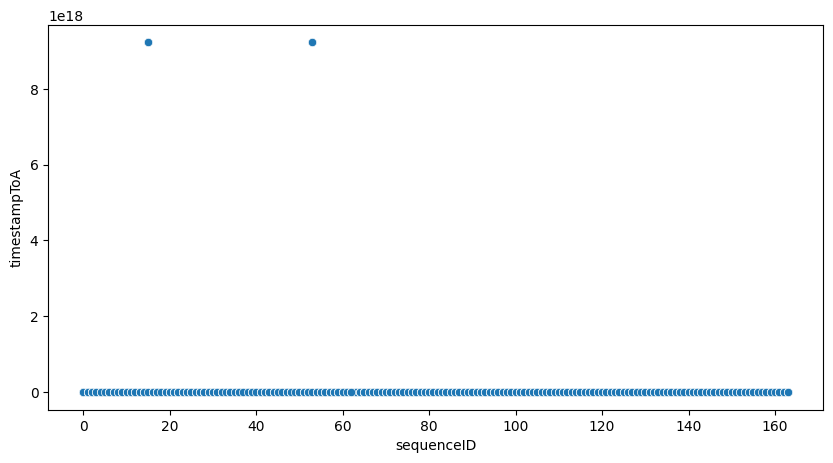

In [8]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='sequenceID', y='timestampToA')
plt.show()

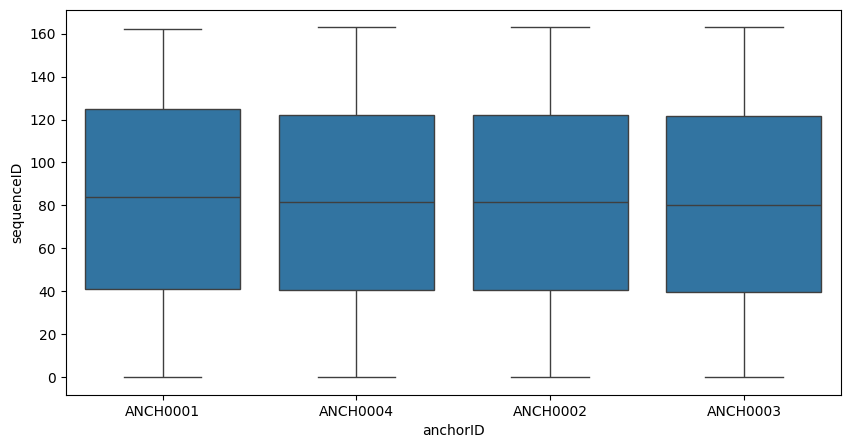

In [9]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='anchorID', y='sequenceID')
plt.show()

Scatterplot показывает зависимость сигналов во времени.

Boxplot показывает распределение сигналов по устройствам.

Каждый график подчеркивает разные аспекты данных.